In [179]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as shc
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

In [180]:
df = pd.read_csv('world-data-2023.csv')

In [181]:
drop_features = ['Abbreviation', 'Capital/Major City', 'Latitude', 'Longitude',
                 'Official language','Density\n(P/Km2)','Calling Code','Currency-Code',
                 'CPI Change (%)','Birth Rate','Co2-Emissions','CPI Change (%)',
                 'Fertility Rate','Gross primary education enrollment (%)',
                 'Gross tertiary education enrollment (%)','Minimum wage',
                 'Out of pocket health expenditure','Physicians per thousand',
                 'Tax revenue (%)','Total tax rate','Maternal mortality ratio',
                 'Gasoline Price','Largest city','CPI']
df.drop(drop_features, axis=1, inplace=True)
df

,Country,Agricultural Land( %),Land Area(Km2),Armed Forces size,Forested Area (%),GDP,Infant mortality,Life expectancy,Population,Population: Labor force participation (%),Unemployment rate,Urban_population
0,Afghanistan,58.10%,"652,230","323,000",2.10%,"$19,101,353,833",47.9,64.5,"38,041,754",48.90%,11.12%,"9,797,273"
1,Albania,43.10%,"28,748","9,000",28.10%,"$15,278,077,447",7.8,78.5,"2,854,191",55.70%,12.33%,"1,747,593"
2,Algeria,17.40%,"2,381,741","317,000",0.80%,"$169,988,236,398",20.1,76.7,"43,053,054",41.20%,11.70%,"31,510,100"
3,Andorra,40.00%,468,NaN,34.00%,"$3,154,057,987",2.7,NaN,"77,142",NaN,NaN,"67,873"
4,Angola,47.50%,"1,246,700","117,000",46.30%,"$94,635,415,870",51.6,60.8,"31,825,295",77.50%,6.89%,"21,061,025"
...,...,...,...,...,...,...,...,...,...,...,...,...
190,Venezuela,24.50%,"912,050","343,000",52.70%,"$482,359,318,768",21.4,72.1,"28,515,829",59.70%,8.80%,"25,162,368"
191,Vietnam,39.30%,"331,210","522,000",48.10%,"$261,921,244,843",16.5,75.3,"96,462,106",77.40%,2.01%,"35,332,140"
192,Yemen,44.60%,"527,968","40,000",1.00%,"$26,914,402,224",42.9,66.1,"29,161,922",38.00%,12.91%,"10,869,523"
193,Zambia,32.10%,"752,618","16,000",65.20%,"$23,064,722,446",40.4,63.5,"17,861,030",74.60%,11.43%,"7,871,713"


In [182]:
df = df.dropna()
df['Agricultural Land( %)'] = df['Agricultural Land( %)'].str.replace('%', '').astype(float)
df['Land Area(Km2)'] = df['Land Area(Km2)'].str.replace(',', '').astype(int)
df['Armed Forces size'] = df['Armed Forces size'].str.replace(',','').astype(int)
df['Forested Area (%)'] = df['Forested Area (%)'].str.replace('%','').astype(float)
df['Population'] = df['Population'].str.replace(',','').astype(int)
df['Population: Labor force participation (%)'] = df['Population: Labor force participation (%)'].str.replace('%','').astype(float)
df['Unemployment rate'] = df['Unemployment rate'].str.replace('%','').astype(float)
df['Urban_population'] = df['Urban_population'].str.replace(',','').astype(int)
df['GDP'] = df['GDP'].str.replace('$', '')
df['GDP'] = df['GDP'].str.replace(',', '').astype('longlong')
df

C:\Users\compro\AppData\Local\Temp\ipykernel_4632\2311956460.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Agricultural Land( %)'] = df['Agricultural Land( %)'].str.replace('%', '').astype(float)
C:\Users\compro\AppData\Local\Temp\ipykernel_4632\2311956460.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Land Area(Km2)'] = df['Land Area(Km2)'].str.replace(',', '').astype(int)
C:\Users\compro\AppData\Local\Temp\ipykernel_4632\2311956460.py:4: SettingWithCopyWarning: 
A value is trying to be 

,Country,Agricultural Land( %),Land Area(Km2),Armed Forces size,Forested Area (%),GDP,Infant mortality,Life expectancy,Population,Population: Labor force participation (%),Unemployment rate,Urban_population
0,Afghanistan,58.1,652230,323000,2.1,19101353833,47.9,64.5,38041754,48.9,11.12,9797273
1,Albania,43.1,28748,9000,28.1,15278077447,7.8,78.5,2854191,55.7,12.33,1747593
2,Algeria,17.4,2381741,317000,0.8,169988236398,20.1,76.7,43053054,41.2,11.70,31510100
4,Angola,47.5,1246700,117000,46.3,94635415870,51.6,60.8,31825295,77.5,6.89,21061025
6,Argentina,54.3,2780400,105000,9.8,449663446954,8.8,76.5,44938712,61.3,9.79,41339571
...,...,...,...,...,...,...,...,...,...,...,...,...
190,Venezuela,24.5,912050,343000,52.7,482359318768,21.4,72.1,28515829,59.7,8.80,25162368
191,Vietnam,39.3,331210,522000,48.1,261921244843,16.5,75.3,96462106,77.4,2.01,35332140
192,Yemen,44.6,527968,40000,1.0,26914402224,42.9,66.1,29161922,38.0,12.91,10869523
193,Zambia,32.1,752618,16000,65.2,23064722446,40.4,63.5,17861030,74.6,11.43,7871713


In [183]:
df_top20=df.head(20)
df_top20 = pd.DataFrame(df_top20)
df_top20 

,Country,Agricultural Land( %),Land Area(Km2),Armed Forces size,Forested Area (%),GDP,Infant mortality,Life expectancy,Population,Population: Labor force participation (%),Unemployment rate,Urban_population
0,Afghanistan,58.1,652230,323000,2.1,19101353833,47.9,64.5,38041754,48.9,11.12,9797273
1,Albania,43.1,28748,9000,28.1,15278077447,7.8,78.5,2854191,55.7,12.33,1747593
2,Algeria,17.4,2381741,317000,0.8,169988236398,20.1,76.7,43053054,41.2,11.70,31510100
4,Angola,47.5,1246700,117000,46.3,94635415870,51.6,60.8,31825295,77.5,6.89,21061025
6,Argentina,54.3,2780400,105000,9.8,449663446954,8.8,76.5,44938712,61.3,9.79,41339571
7,Armenia,58.9,29743,49000,11.7,13672802158,11.0,74.9,2957731,55.6,16.99,1869848
8,Australia,48.2,7741220,58000,16.3,1392680589329,3.1,82.7,25766605,65.5,5.27,21844756
9,Austria,32.4,83871,21000,46.9,446314739528,2.9,81.6,8877067,60.7,4.67,5194416
10,Azerbaijan,57.7,86600,82000,14.1,39207000000,19.2,72.9,10023318,66.5,5.51,5616165
11,The Bahamas,1.4,13880,1000,51.4,12827000000,8.3,73.8,389482,74.6,10.36,323784


In [184]:
df_top20['Country'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina',
       'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'The Bahamas',
       'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium',
       'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina'],
      dtype=object)

In [185]:
features = df_top20.drop(columns=['Country'])
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

In [186]:
scaled_features

array([[ 1.10794485, -0.10492887,  2.47260192, -1.28799391, -0.50925497,
         1.81212123, -1.62023832,  0.45838428, -1.40333335,  0.73838716,
        -0.13140174],
       [ 0.31580125, -0.45740691, -0.73035601, -0.04816267, -0.52109082,
        -0.58609862,  0.72671838, -0.50651153, -0.68502949,  0.9956427 ,
        -0.64204285],
       [-1.04140479,  0.87282934,  2.4113989 , -1.34998547, -0.04214929,
         0.14951495,  0.4249668 ,  0.59580165, -2.21670684,  0.86169973,
         1.2459775 ],
       [ 0.54816337,  0.23114758,  0.37129831,  0.81971919, -0.27542159,
         2.03340336, -2.24050545,  0.28791964,  1.61776818, -0.16094416,
         0.58312789],
       [ 0.90726847,  1.0982064 ,  0.24889227, -0.92081312,  0.82365083,
        -0.52629263,  0.39143885,  0.64750922, -0.09348513,  0.45561868,
         1.86952179],
       [ 1.15019251, -0.4568444 , -0.32233589, -0.83021007, -0.52606033,
        -0.39471948,  0.12321523, -0.50367231, -0.69559278,  1.98639541,
        -0.634

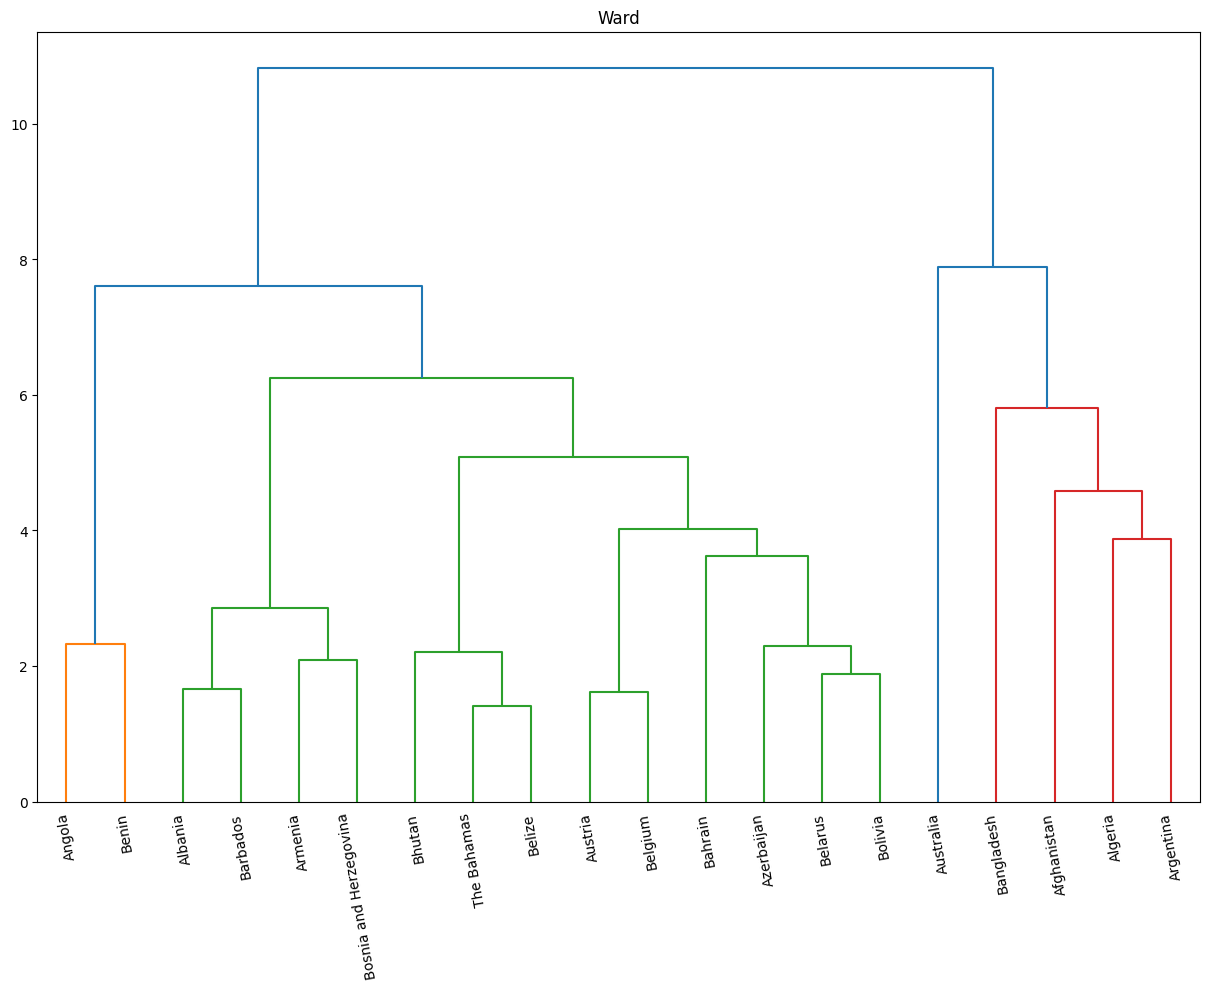

In [187]:
plt.figure(figsize=(15, 10))
plt.title("Ward")
dend = shc.dendrogram(shc.linkage(scaled_features, method='ward'), labels=df_top20['Country'].values, leaf_rotation=100, leaf_font_size=10)
plt.show()

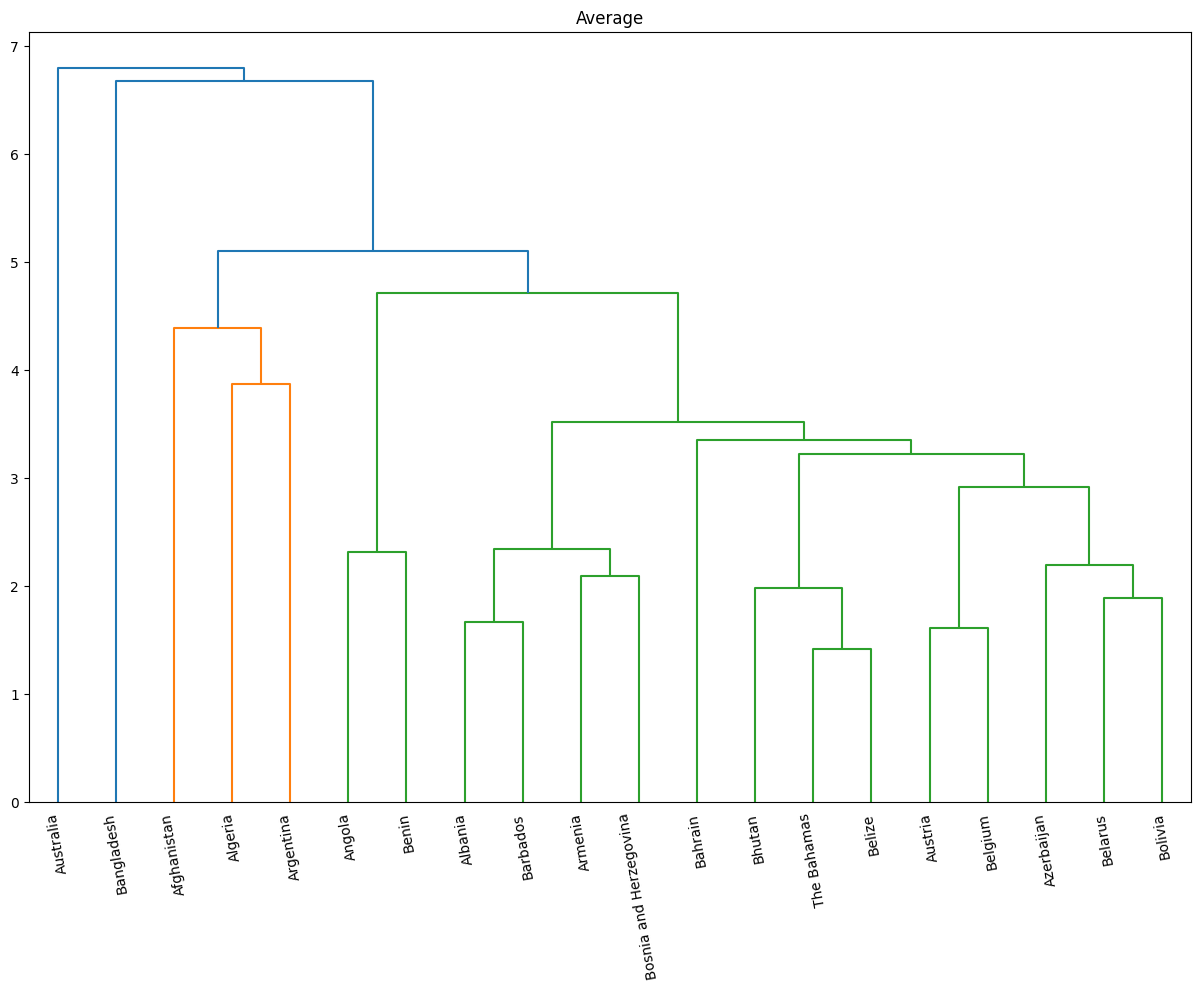

In [188]:
plt.figure(figsize=(15, 10))
plt.title("Average")
dend = shc.dendrogram(shc.linkage(scaled_features, method='average'), labels=df_top20['Country'].values, leaf_rotation=100, leaf_font_size=10)
plt.show()

In [189]:
from sklearn.cluster import KMeans

In [190]:
kmeans = KMeans(n_clusters=4, random_state=0)
y_kmeans = kmeans.fit_predict(scaled_features)

c:\Users\compro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [191]:
df_top20['Cluster_n4'] = y_kmeans
print(df_top20)

                   Country  Agricultural Land( %)  Land Area(Km2)  \
0              Afghanistan                   58.1          652230   
1                  Albania                   43.1           28748   
2                  Algeria                   17.4         2381741   
4                   Angola                   47.5         1246700   
6                Argentina                   54.3         2780400   
7                  Armenia                   58.9           29743   
8                Australia                   48.2         7741220   
9                  Austria                   32.4           83871   
10              Azerbaijan                   57.7           86600   
11             The Bahamas                    1.4           13880   
12                 Bahrain                   11.1             765   
13              Bangladesh                   70.6          148460   
14                Barbados                   23.3             430   
15                 Belarus        

In [192]:
print("4 중심점:")
print(kmeans.cluster_centers_)

4 중심점:
[[ 0.1297942  -0.44102781 -0.39260602 -0.20022745 -0.16560147 -0.59540177
   0.55535329 -0.43014216 -0.21672354  0.2437195  -0.49682024]
 [ 0.68546827  0.36909442  1.64126092 -1.10559566  0.16013477  0.4709721
  -0.27912021  1.42620795 -1.01249154  0.33018004  1.52500101]
 [ 0.58513008  3.90274623 -0.23053137 -0.61085531  3.74298128 -0.86718673
   1.43080539  0.12178126  0.35017313 -0.50536893  0.63284481]
 [-0.74919182 -0.23497893 -0.46684302  1.13921416 -0.48218453  0.72365237
  -0.88541735 -0.32588893  0.94171749 -0.50147112 -0.37691112]]


In [193]:
kmeans = KMeans(n_clusters=3, random_state=0)
y_kmeans = kmeans.fit_predict(scaled_features)

c:\Users\compro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [194]:
df_top20['Cluster_n3'] = y_kmeans

for i in range(len(df_top20)):
    print(df_top20.iloc[i]['Country'], df_top20.iloc[i]['Cluster_n3'])

Afghanistan 1
Albania 1
Algeria 1
Angola 0
Argentina 1
Armenia 1
Australia 2
Austria 0
Azerbaijan 1
The Bahamas 0
Bahrain 0
Bangladesh 1
Barbados 0
Belarus 0
Belgium 1
Belize 0
Benin 0
Bhutan 0
Bolivia 0
Bosnia and Herzegovina 1


In [195]:
print("3 중심점:")
print(kmeans.cluster_centers_)

3 중심점:
[[-0.65906348 -0.31390554 -0.40904017  0.62897592 -0.3454165   0.15011301
  -0.27241462 -0.37423789  0.71988835 -0.51961366 -0.43701338]
 [ 0.6672783  -0.08485454  0.48010367 -0.63098932 -0.0320907  -0.07043816
   0.14370453  0.40228862 -0.83878407  0.63350061  0.41525433]
 [ 0.58513008  3.90274623 -0.23053137 -0.61085531  3.74298128 -0.86718673
   1.43080539  0.12178126  0.35017313 -0.50536893  0.63284481]]


In [196]:
for i in range(len(df_top20)):
    print(df_top20.iloc[i]['Country'], df_top20.iloc[i]['Cluster_n4'])

Afghanistan 1
Albania 0
Algeria 1
Angola 3
Argentina 1
Armenia 0
Australia 2
Austria 0
Azerbaijan 0
The Bahamas 3
Bahrain 0
Bangladesh 1
Barbados 0
Belarus 0
Belgium 0
Belize 3
Benin 3
Bhutan 3
Bolivia 3
Bosnia and Herzegovina 0


In [197]:
drop_features = ['Country', 'Cluster_n3', 'Cluster_n4']
df_top20.drop(drop_features, axis=1, inplace=True)

In [198]:
df_top20

,Agricultural Land( %),Land Area(Km2),Armed Forces size,Forested Area (%),GDP,Infant mortality,Life expectancy,Population,Population: Labor force participation (%),Unemployment rate,Urban_population
0,58.1,652230,323000,2.1,19101353833,47.9,64.5,38041754,48.9,11.12,9797273
1,43.1,28748,9000,28.1,15278077447,7.8,78.5,2854191,55.7,12.33,1747593
2,17.4,2381741,317000,0.8,169988236398,20.1,76.7,43053054,41.2,11.70,31510100
4,47.5,1246700,117000,46.3,94635415870,51.6,60.8,31825295,77.5,6.89,21061025
6,54.3,2780400,105000,9.8,449663446954,8.8,76.5,44938712,61.3,9.79,41339571
7,58.9,29743,49000,11.7,13672802158,11.0,74.9,2957731,55.6,16.99,1869848
8,48.2,7741220,58000,16.3,1392680589329,3.1,82.7,25766605,65.5,5.27,21844756
9,32.4,83871,21000,46.9,446314739528,2.9,81.6,8877067,60.7,4.67,5194416
10,57.7,86600,82000,14.1,39207000000,19.2,72.9,10023318,66.5,5.51,5616165
11,1.4,13880,1000,51.4,12827000000,8.3,73.8,389482,74.6,10.36,323784
